# EE 608 — E-Commerce Shipment Optimization (ILP)

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from pulp import LpProblem, LpVariable, LpMinimize, value, LpStatus, PULP_CBC_CMD
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load & Fix Data

In [2]:
df = pd.read_csv("data/ecommerce_shipments.csv")
df["on_time"] = 1 - df["Reached.on.Time_Y.N"]

print("Total records:", len(df))
print("Overall on-time rate:", round(df["on_time"].mean(), 4))
print()
print(df.groupby("Mode_of_Shipment")[["Cost_of_the_Product", "on_time"]].mean().round(4))

Total records: 10999
Overall on-time rate: 0.4033

                  Cost_of_the_Product  on_time
Mode_of_Shipment                              
Flight                       209.3067   0.3984
Road                         210.4756   0.4119
Ship                         210.3431   0.4024


## 2. Train / Validation / Test Split (70 / 15 / 15)

In [3]:
train, temp = train_test_split(df, test_size=0.30, random_state=42)
val, test = train_test_split(temp, test_size=0.50, random_state=42)

print("Train:", len(train))
print("Val:  ", len(val))
print("Test: ", len(test))

Train: 7699
Val:   1650
Test:  1650


## 3. Parameter Estimation from Training Set

In [4]:
modes = train.groupby("Mode_of_Shipment")
alpha = modes["Cost_of_the_Product"].mean()
r = modes["on_time"].mean()
N_train = len(train)

print("alpha_m (avg cost per mode):")
print(alpha.round(2))
print()
print("r_m (on-time rate per mode):")
print(r.round(4))

alpha_m (avg cost per mode):
Mode_of_Shipment
Flight    210.17
Road      210.73
Ship      210.72
Name: Cost_of_the_Product, dtype: float64

r_m (on-time rate per mode):
Mode_of_Shipment
Flight    0.4024
Road      0.4176
Ship      0.4038
Name: on_time, dtype: float64


## 4. Feasibility Check & R_min Selection

In [5]:
current_avg = train["on_time"].mean()
R_min = round(min(current_avg + 0.05, r.max() - 0.002), 4)

print("Current avg on-time rate (train):", round(current_avg, 4))
print("Max achievable r_m:", round(r.max(), 4))
print("R_min set to:", R_min)
print("Feasible:", r.max() >= R_min)

Current avg on-time rate (train): 0.4058
Max achievable r_m: 0.4176
R_min set to: 0.4156
Feasible: True


## 5. ILP Solver

Reduced form — 3 variables: n_ship, n_road, n_flight

**minimize** Σ α_m · n_m  
**subject to** Σ n_m = N,  Σ r_m · n_m ≥ R_min · N,  n_m ∈ Z≥0

In [6]:
def solve_shipment(alpha, r, N, R_min, relax=False):
    cat = "Continuous" if relax else "Integer"
    prob = LpProblem("Shipment_Optimization", LpMinimize)

    n_ship = LpVariable("n_ship", lowBound=0, cat=cat)
    n_road = LpVariable("n_road", lowBound=0, cat=cat)
    n_flight = LpVariable("n_flight", lowBound=0, cat=cat)

    prob += alpha["Ship"]*n_ship + alpha["Road"]*n_road + alpha["Flight"]*n_flight
    prob += n_ship + n_road + n_flight == N
    prob += r["Ship"]*n_ship + r["Road"]*n_road + r["Flight"]*n_flight >= R_min * N

    prob.solve(PULP_CBC_CMD(msg=0))

    ns, nr, nf = value(n_ship), value(n_road), value(n_flight)
    cost = value(prob.objective)
    ontime = (r["Ship"]*ns + r["Road"]*nr + r["Flight"]*nf) / N if prob.status == 1 else None

    return {
        "status": LpStatus[prob.status],
        "n_ship": ns, "n_road": nr, "n_flight": nf,
        "total_cost": cost,
        "actual_ontime": ontime
    }

## 6. Solve ILP (Training Set)

In [7]:
ilp = solve_shipment(alpha, r, N_train, R_min, relax=False)

print("Status:", ilp["status"])
print("n_ship:", int(ilp["n_ship"]), "n_road:", int(ilp["n_road"]), "n_flight:", int(ilp["n_flight"]))
print("Total cost:", round(ilp["total_cost"], 2))
print("Actual on-time:", round(ilp["actual_ontime"], 4))
print("R_min target:", R_min)

Status: Optimal
n_ship: 0 n_road: 6679 n_flight: 1020
Total cost: 1621849.79
Actual on-time: 0.4156
R_min target: 0.4156


## 7. LP Relaxation & Integrality Gap

In [8]:
lp = solve_shipment(alpha, r, N_train, R_min, relax=True)

print("LP relaxation cost:", round(lp["total_cost"], 4))
print("n_ship:", round(lp["n_ship"], 4), "n_road:", round(lp["n_road"], 4), "n_flight:", round(lp["n_flight"], 4))

gap = ilp["total_cost"] - lp["total_cost"]
gap_pct = 100 * gap / lp["total_cost"]
print()
print("ILP cost:", round(ilp["total_cost"], 4))
print("LP cost:", round(lp["total_cost"], 4))
print("Integrality gap:", round(gap, 4))
print("Gap (%):", round(gap_pct, 6), "%")

LP relaxation cost: 1621849.5584
n_ship: 0.0 n_road: 6678.5877 n_flight: 1020.4123

ILP cost: 1621849.7901
LP cost: 1621849.5584
Integrality gap: 0.2317
Gap (%): 1.4e-05 %


## 8. Baseline Comparison (Historical vs Optimized)

In [9]:
baseline_cost = train["Cost_of_the_Product"].sum()
baseline_ontime = train["on_time"].mean()

print("Historical (train)")
print("Total cost:", round(baseline_cost, 2))
print("On-time rate:", round(baseline_ontime, 4))
print()
print("ILP Optimized")
print("Total cost:", round(ilp["total_cost"], 2))
print("On-time rate:", round(ilp["actual_ontime"], 4))
print()
print("Cost reduction:", round(baseline_cost - ilp["total_cost"], 2))
print("On-time improvement:", round(ilp["actual_ontime"] - baseline_ontime, 4))

Historical (train)
Total cost: 1621676
On-time rate: 0.4058

ILP Optimized
Total cost: 1621849.79
On-time rate: 0.4156

Cost reduction: -173.79
On-time improvement: 0.0098


## 9. Evaluate on Validation & Test Sets

In [10]:
def evaluate_split(split_df, alpha, r, R_min, label):
    N = len(split_df)
    res = solve_shipment(alpha, r, N, R_min, relax=False)
    hist_cost = split_df["Cost_of_the_Product"].sum()
    hist_ontime = split_df["on_time"].mean()
    print(label, "N =", N)
    print("ILP cost:", round(res["total_cost"], 2))
    print("Historical cost:", round(hist_cost, 2))
    print("Cost reduction:", round(hist_cost - res["total_cost"], 2))
    print("ILP on-time rate:", round(res["actual_ontime"], 4))
    print("Historical on-time:", round(hist_ontime, 4))
    print()
    return res

val_res = evaluate_split(val, alpha, r, R_min, "Validation Set")
test_res = evaluate_split(test, alpha, r, R_min, "Test Set")

Validation Set N = 1650
ILP cost: 347584.72
Historical cost: 343381
Cost reduction: -4203.72
ILP on-time rate: 0.4156
Historical on-time: 0.4115

Test Set N = 1650
ILP cost: 347584.72
Historical cost: 346898
Cost reduction: -686.72
ILP on-time rate: 0.4156
Historical on-time: 0.3836



## 10. R_min Sensitivity Sweep

In [11]:
r_min_values = [0.35, 0.38, 0.40, 0.405, 0.410, 0.415, round(r.max(), 4), round(r.max() + 0.005, 4)]
sweep = []

for rm in r_min_values:
    if r.max() < rm:
        sweep.append({"R_min": rm, "feasible": False,
                      "total_cost": None, "actual_ontime": None,
                      "n_ship": None, "n_road": None, "n_flight": None})
        continue
    res = solve_shipment(alpha, r, N_train, rm, relax=False)
    sweep.append({
        "R_min": rm,
        "feasible": res["status"] == "Optimal",
        "total_cost": round(res["total_cost"], 2),
        "actual_ontime": round(res["actual_ontime"], 4),
        "n_ship": int(res["n_ship"]),
        "n_road": int(res["n_road"]),
        "n_flight": int(res["n_flight"])
    })

sweep_df = pd.DataFrame(sweep)
print(sweep_df.to_string(index=False))

 R_min  feasible  total_cost  actual_ontime  n_ship  n_road  n_flight
0.3500      True  1618096.68         0.4024     0.0     0.0    7699.0
0.3800      True  1618096.68         0.4024     0.0     0.0    7699.0
0.4000      True  1618096.68         0.4024     0.0     0.0    7699.0
0.4050      True  1618838.43         0.4050     0.0  1320.0    6379.0
0.4100      True  1620258.98         0.4100     0.0  3848.0    3851.0
0.4150      True  1621679.53         0.4150     0.0  6376.0    1323.0
0.4176      True  1622417.90         0.4176     0.0  7690.0       9.0
0.4226     False         NaN            NaN     NaN     NaN       NaN


## 11. Visualizations

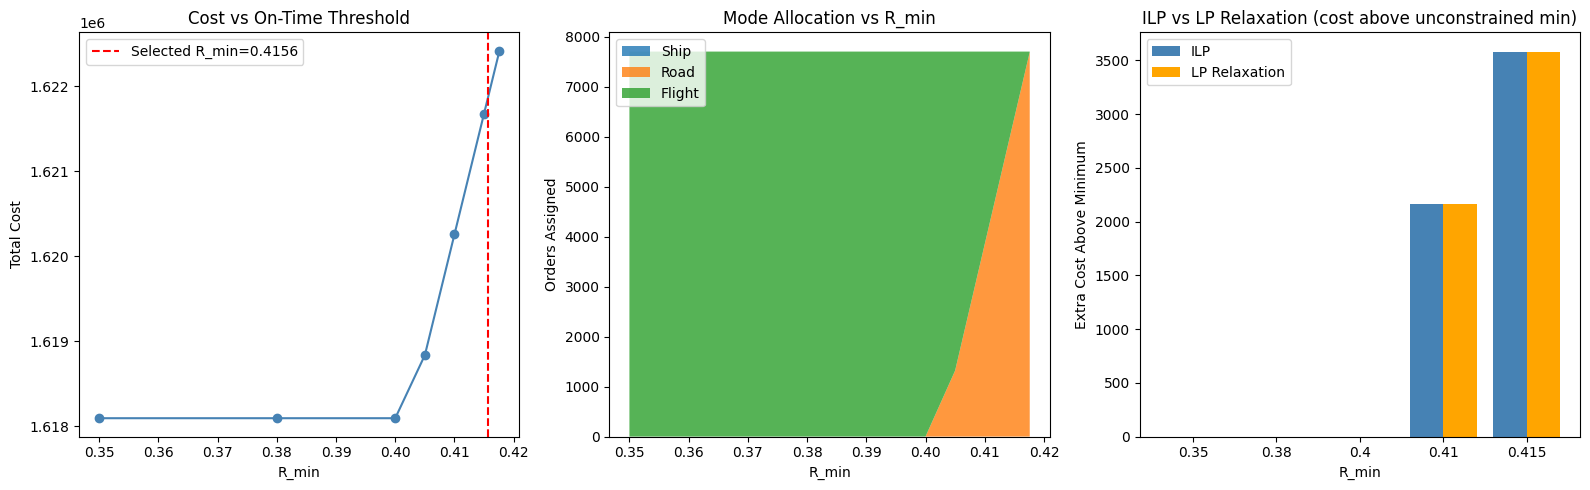

In [12]:
feasible = sweep_df[sweep_df["feasible"]].copy()
base_cost = feasible["total_cost"].min()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(feasible["R_min"], feasible["total_cost"], marker="o", color="steelblue")
axes[0].axvline(R_min, color="red", linestyle="--", label=f"Selected R_min={R_min}")
axes[0].set_xlabel("R_min")
axes[0].set_ylabel("Total Cost")
axes[0].set_title("Cost vs On-Time Threshold")
axes[0].legend()

axes[1].stackplot(
    feasible["R_min"],
    feasible["n_ship"], feasible["n_road"], feasible["n_flight"],
    labels=["Ship", "Road", "Flight"], alpha=0.8
)
axes[1].set_xlabel("R_min")
axes[1].set_ylabel("Orders Assigned")
axes[1].set_title("Mode Allocation vs R_min")
axes[1].legend(loc="upper left")

rm_compare = [rm for rm in [0.35, 0.38, 0.40, 0.41, 0.415] if r.max() >= rm]
ilp_costs = [solve_shipment(alpha, r, N_train, rm, relax=False)["total_cost"] - base_cost for rm in rm_compare]
lp_costs  = [solve_shipment(alpha, r, N_train, rm, relax=True)["total_cost"]  - base_cost for rm in rm_compare]
x = np.arange(len(rm_compare))
axes[2].bar(x - 0.2, ilp_costs, width=0.4, label="ILP", color="steelblue")
axes[2].bar(x + 0.2, lp_costs,  width=0.4, label="LP Relaxation", color="orange")
axes[2].set_xticks(x)
axes[2].set_xticklabels([str(v) for v in rm_compare])
axes[2].set_xlabel("R_min")
axes[2].set_ylabel("Extra Cost Above Minimum")
axes[2].set_title("ILP vs LP Relaxation (cost above unconstrained min)")
axes[2].legend()

plt.tight_layout()
plt.savefig("results.png", dpi=150)
plt.show()

## 12. Summary

In [13]:
print("Model Parameters (from train)")
print("alpha (avg cost):", alpha.round(2).to_dict())
print("r (on-time rate):", r.round(4).to_dict())
print()
print("ILP Solution (train, R_min =", R_min, ")")
print("n_ship:", int(ilp["n_ship"]), "n_road:", int(ilp["n_road"]), "n_flight:", int(ilp["n_flight"]))
print("Total cost:", round(ilp["total_cost"], 2))
print("On-time rate:", round(ilp["actual_ontime"], 4))
print()
print("Integrality Gap")
print("ILP cost:", round(ilp["total_cost"], 4))
print("LP cost:", round(lp["total_cost"], 4))
print("Gap:", round(ilp["total_cost"] - lp["total_cost"], 4))
print("Gap (%):", round(100 * (ilp["total_cost"] - lp["total_cost"]) / lp["total_cost"], 6), "%")
print()
print("Cheapest mode:", alpha.idxmin(), "at avg cost", round(alpha.min(), 2))
print("Best on-time mode:", r.idxmax(), "at rate", round(r.max(), 4))

Model Parameters (from train)
alpha (avg cost): {'Flight': 210.17, 'Road': 210.73, 'Ship': 210.72}
r (on-time rate): {'Flight': 0.4024, 'Road': 0.4176, 'Ship': 0.4038}

ILP Solution (train, R_min = 0.4156 )
n_ship: 0 n_road: 6679 n_flight: 1020
Total cost: 1621849.79
On-time rate: 0.4156

Integrality Gap
ILP cost: 1621849.7901
LP cost: 1621849.5584
Gap: 0.2317
Gap (%): 1.4e-05 %

Cheapest mode: Flight at avg cost 210.17
Best on-time mode: Road at rate 0.4176
